In [ ]:

from google.colab import files
uploaded = files.upload()


Saving superstore_sales_final.xlsx to superstore_sales_final.xlsx


In [ ]:
#Loading dataset
import pandas as pd
file_name = list(uploaded.keys())[0]
# Read file
df = pd.read_excel(file_name)
df.columns = df.columns.str.strip()

print("First 5 rows:")
display(df.head())


First 5 rows:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium,2011


In [ ]:
#Verification of dataset
print("Shape:", df.shape)
print("Columns:", df.columns)
print("\nData Info :")
df.info()

Shape: (51290, 21)
Columns: Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

Data Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market    

# Data Preprocessing

---



In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Convert date column (AFTER standardization)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Handle missing values
df = df.dropna(subset=['order_date', 'sales'])
df = df.fillna(method='ffill')

# Sort by date
df = df.sort_values(by='order_date')

# Final check
print("Final shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Final shape: (51290, 21)

Missing values:
 order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


/tmp/ipykernel_4063/2259390922.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


# Data Reduction Using Time-Series Aggregation

---



In [ ]:
#Data Aggregation (Time-Series Conversion)

# Aggregate sales by date
daily_sales = df.groupby('order_date')['sales'].sum().reset_index()

# Sort by date
daily_sales = daily_sales.sort_values(by='order_date')

# Check structure before setting index
print("Columns before setting index:", daily_sales.columns)

# Set 'order_date' as index ONLY if it's a column
if 'order_date' in daily_sales.columns:
    daily_sales.set_index('order_date', inplace=True)

# Final verification
print("\nFinal dataset shape:", daily_sales.shape)
print("\nIndex type:", type(daily_sales.index))

# Display data
daily_sales.head()

Columns before setting index: Index(['order_date', 'sales'], dtype='object')

Final dataset shape: (1430, 1)

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,sales
order_date,
2011-01-01,808.56300
2011-01-02,314.22000
2011-01-03,4503.53720
2011-01-04,2808.87024
2011-01-05,3662.31000


# Exploratory Data Analysis

---



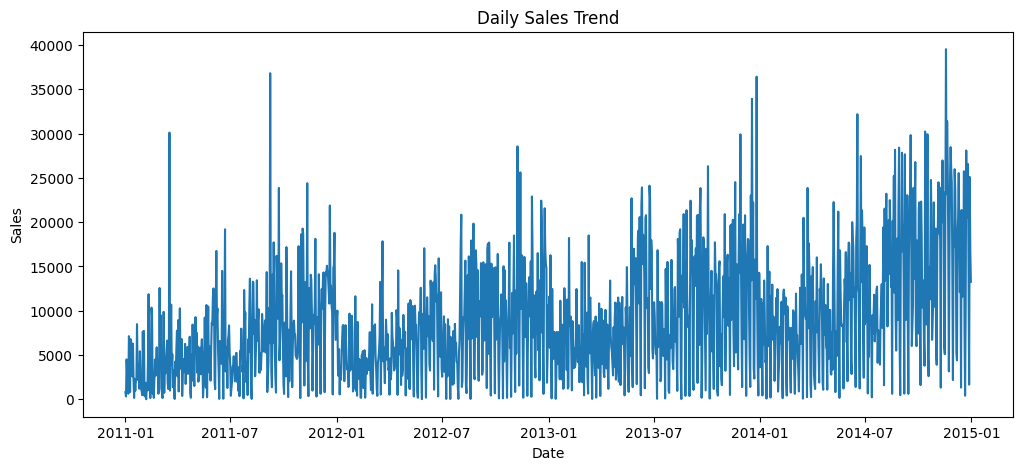

In [ ]:
#Plotting Sales Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales['sales'])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

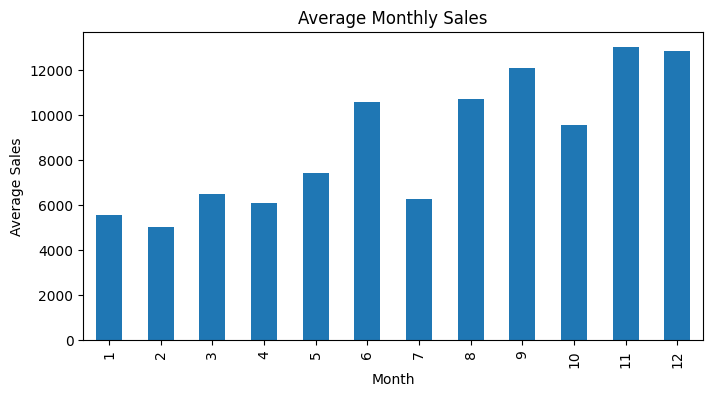

In [ ]:
#Monthly Sales Pattern
# Extract month
daily_sales['month'] = daily_sales.index.month

# Group by month
monthly_sales = daily_sales.groupby('month')['sales'].mean()

# Plot
plt.figure(figsize=(8,4))
monthly_sales.plot(kind='bar')

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

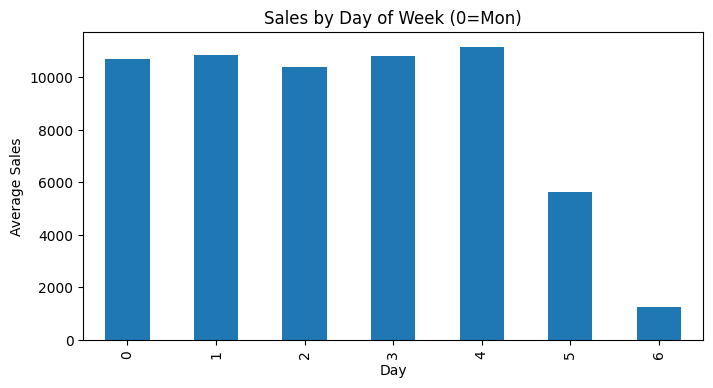

In [ ]:
#Day of Week Patterns
# Extract day of week
daily_sales['day_of_week'] = daily_sales.index.dayofweek

# Group by day
dow_sales = daily_sales.groupby('day_of_week')['sales'].mean()

# Plot
plt.figure(figsize=(8,4))
dow_sales.plot(kind='bar')

plt.title("Sales by Day of Week (0=Mon)")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.show()

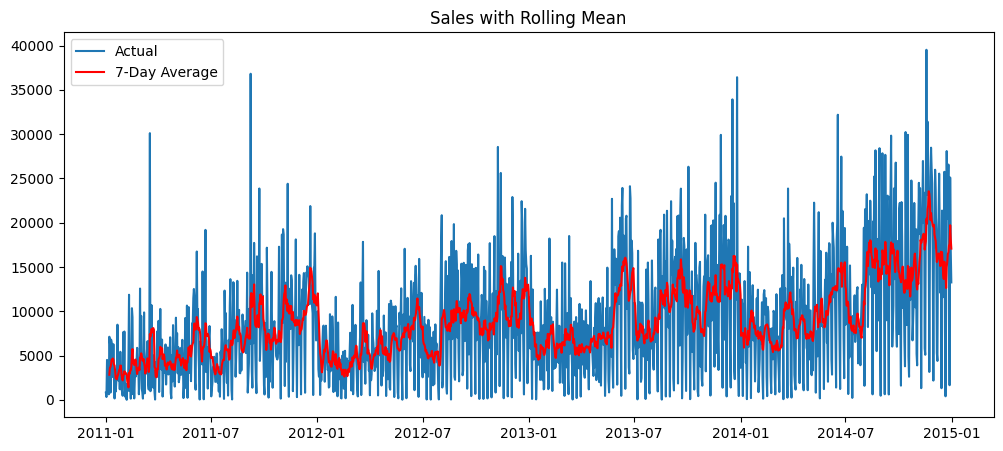

In [ ]:
#Trend Smoothening
# Rolling average (7 days)
rolling_mean = daily_sales['sales'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales['sales'], label='Actual')
plt.plot(daily_sales.index, rolling_mean, label='7-Day Average', color='red')

plt.legend()
plt.title("Sales with Rolling Mean")
plt.show()

#                     ARIMA MODEL

---



In [ ]:
# Extract sales series
sales_series = daily_sales['sales']

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(sales_series, order=(2,1,2))
model_fit = model.fit()

# Print summary
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1430
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -14360.403
Date:                Wed, 01 Apr 2026   AIC                          28730.806
Time:                        19:20:24   BIC                          28757.129
Sample:                             0   HQIC                         28740.636
                               - 1430                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7591      0.046     16.504      0.000       0.669       0.849
ar.L2         -0.3007      0.023    -13.021      0.000      -0.346      -0.255
ma.L1         -1.6029      0.044    -36.149      0.0

In [ ]:
# Generate predictions
arima_pred = model_fit.predict(start=0, end=len(sales_series)-1)

# Convert to pandas Series (for safety)
arima_pred = pd.Series(arima_pred, index=sales_series.index)

arima_pred.head()

,predicted_mean
order_date,
2011-01-01,0.000000
2011-01-02,537.634231
2011-01-03,268.693499
2011-01-04,2145.152900
2011-01-05,1356.981117


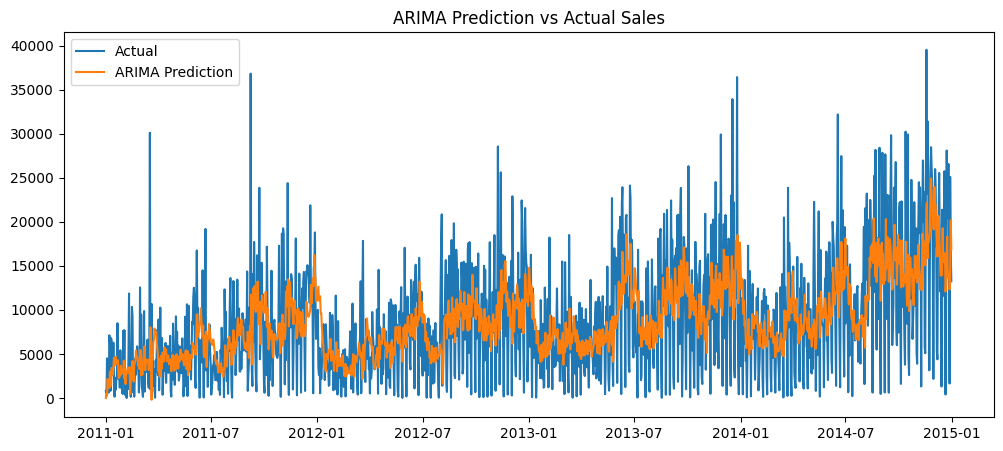

In [ ]:
#ARIMA vs Actual Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(sales_series, label='Actual')
plt.plot(arima_pred, label='ARIMA Prediction')

plt.legend()
plt.title("ARIMA Prediction vs Actual Sales")

plt.show()

In [ ]:
#Checking Model Error
from sklearn.metrics import mean_absolute_error

mae_arima = mean_absolute_error(sales_series, arima_pred)

print("ARIMA MAE:", mae_arima)

ARIMA MAE: 4304.214503353382


# Residual Calculation (Core of ChronoForest)

---



In [ ]:
# Calculate residuals
residuals = sales_series - arima_pred

# Display
residuals.head()

,0
order_date,
2011-01-01,808.563000
2011-01-02,-223.414231
2011-01-03,4234.843701
2011-01-04,663.717340
2011-01-05,2305.328883


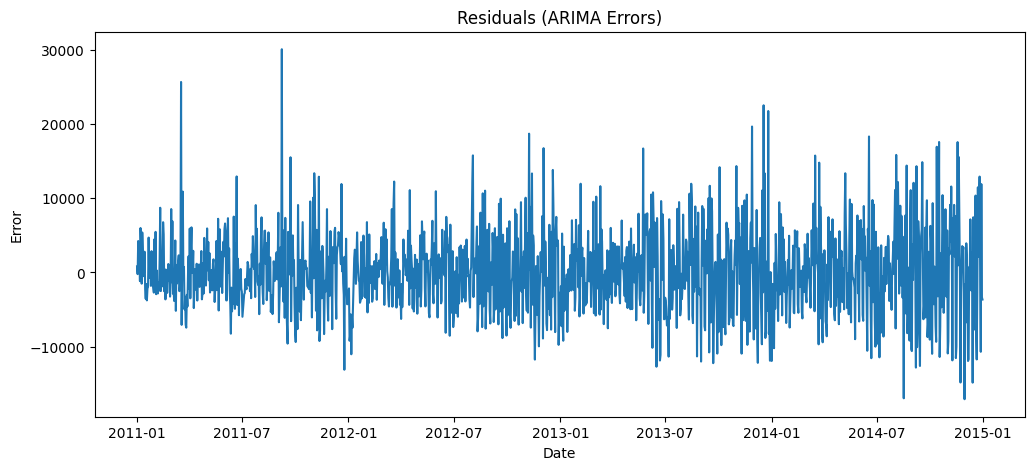

In [ ]:
#Plot Residuals
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(residuals)

plt.title("Residuals (ARIMA Errors)")
plt.xlabel("Date")
plt.ylabel("Error")

plt.show()

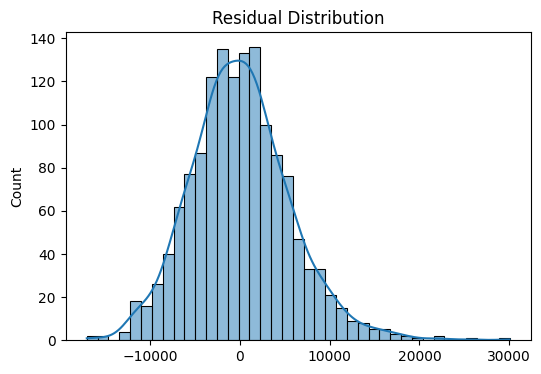

In [ ]:
#Residual Distribution
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.show()

In [ ]:
#Checking Residual Mean
print("Residual Mean:", residuals.mean())

Residual Mean: 81.65287866625364


# Random Forest

---



In [ ]:
# Create features again (if not present)

daily_sales['month'] = daily_sales.index.month
daily_sales['day_of_week'] = daily_sales.index.dayofweek

# Features
X = daily_sales[['month', 'day_of_week']]

# Target = residuals
y = residuals

X.head()

,month,day_of_week
order_date,,
2011-01-01,1,5
2011-01-02,1,6
2011-01-03,1,0
2011-01-04,1,1
2011-01-05,1,2


In [ ]:
#Train Random Forest
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf.fit(X, y)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict residuals
rf_pred = rf.predict(X)

rf_pred[:5]

array([-1740.51864098, -4626.06851777,  1858.14912631, -1128.9626547 ,
        -740.61398176])

In [ ]:
#ChronoForest Prediction
# Final prediction
final_pred = arima_pred + rf_pred
# Remove negative predictions
final_pred = final_pred.clip(lower=0)
final_pred[:5]

,predicted_mean
order_date,
2011-01-01,0.000000
2011-01-02,0.000000
2011-01-03,2126.842625
2011-01-04,1016.190246
2011-01-05,616.367135


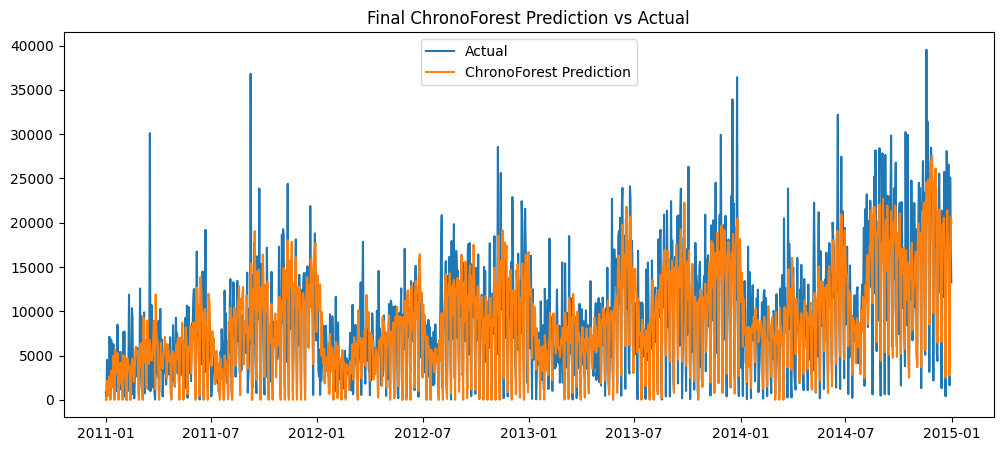

In [ ]:
#Plot of final Model
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(sales_series, label='Actual')
plt.plot(final_pred, label='ChronoForest Prediction')

plt.legend()
plt.title("Final ChronoForest Prediction vs Actual")

plt.show()

In [ ]:
#Evaluate Final Model
from sklearn.metrics import mean_absolute_error

mae_final = mean_absolute_error(sales_series, final_pred)

print("Final Model MAE:", mae_final)

Final Model MAE: 3227.1081273621494
